# 07 — Selección de Features con SHAP + Boruta

**Materia:** Laboratorio de Implementación II · Universidad Austral · Abril 2026

**Autores:** Roxana Alberti · Sandra Sschicchi · Fernando Paganini · Baltazar Villanueva · Paula Calviello · Rosana Martinez

---

## ¿Qué hace este notebook?

Partimos de las **48 features del FE v4** (notebook 05) y analizamos cuáles tienen impacto real en la predicción de velocidad de adopción. Usamos dos técnicas complementarias:

### 1. Boruta
Algoritmo estadístico que crea copias aleatorias (*shadow features*) de cada variable y compara la importancia real contra esas sombras en múltiples iteraciones. Una feature se **Acepta** si supera consistentemente a sus sombras, se **Rechaza** si queda por debajo, y queda **Tentativa** si no hay certeza estadística después de 50 iteraciones.

**Resultado:** Boruta con Random Forest es muy conservador — solo acepta `avg_label_score`. Esto no significa que las demás sean inútiles: RF no aprovecha las features tan bien como LightGBM, por eso la mayoría no superan el umbral estadístico.

### 2. SHAP (SHapley Additive exPlanations)
Calcula la contribución real de cada feature a cada predicción individual usando teoría de juegos cooperativos. A diferencia del feature importance de LightGBM (que mide frecuencia de splits), SHAP mide **cuánto cambia la predicción** cuando incluimos o excluimos esa variable.

**Resultado clave:** las features nuevas del FE v4 (`rescuer_n_pets`, `age_rel_breed`) son las **#1 y #2 en impacto real**, superando incluso al target encoding de Breed1.

### 3. Selección por SHAP
Usamos el umbral SHAP ≥ 0.04 para quedarnos con 25 features. El modelo resultante obtiene kappa 0.3738 — solo 0.013 menos que el modelo completo de 48 features, con la mitad de variables.

| Modelo | Features | Kappa Test |
|---|---|---|
| FE v4 + CV completo | 48 | **0.3867** |
| SHAP selection | 25 | 0.3738 |
| Boruta (RF) selection | 2 | 0.2533 |

**Conclusión:** el modelo con todas las features de FE v4 sigue siendo el mejor. SHAP confirma qué features importan y por qué.

## Sección A: Imports y datos

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from pathlib import Path
import warnings, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd()
while not (BASE_DIR / 'input').exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent
print(f'BASE_DIR: {BASE_DIR}')

SEED = 42
train_raw = pd.read_csv(BASE_DIR / 'input/train/train.csv')
sent_df   = pd.read_csv(BASE_DIR / 'input/train_sentiment_features.csv')
meta_df   = pd.read_csv(BASE_DIR / 'input/train_metadata_features.csv')
train_raw['desc_length'] = train_raw['Description'].fillna('').apply(len)

df = (train_raw
      .merge(sent_df[['PetID','sentiment_score','sentiment_magnitude','n_sentences']], on='PetID', how='left')
      .merge(meta_df[['PetID','avg_label_score','n_labels','crop_confidence']], on='PetID', how='left')
      .fillna(0))

train, test = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['AdoptionSpeed'])
print(f'Train: {len(train)} | Test: {len(test)}')


BASE_DIR: C:\Users\User\Desktop\MCD\Laboratorio de Implementacion II\GitHub\UA_MDM_Labo2


Train: 11994 | Test: 2999


## Sección B: Feature Engineering v4

In [2]:
def target_encode(train_df, test_df, col, target='AdoptionSpeed', smoothing=10):
    global_mean = train_df[target].mean()
    stats = train_df.groupby(col)[target].agg(['mean', 'count'])
    stats['encoded'] = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    return train_df[col].map(stats['encoded']).fillna(global_mean), test_df[col].map(stats['encoded']).fillna(global_mean)

def add_features_v4(df_):
    df_ = df_.copy()
    df_['HasPhoto']            = (df_['PhotoAmt'] > 0).astype(int)
    df_['HasVideo']            = (df_['VideoAmt'] > 0).astype(int)
    df_['IsFree']              = (df_['Fee'] == 0).astype(int)
    df_['AgeGroup']            = pd.cut(df_['Age'], bins=[-1,3,12,48,9999], labels=[0,1,2,3]).astype(int)
    df_['HealthScore']         = ((df_['Vaccinated']==1).astype(int) + (df_['Dewormed']==1).astype(int) + (df_['Sterilized']==1).astype(int))
    df_['IsPureBreed']         = (df_['Breed2'] == 0).astype(int)
    df_['PhotoPerAnimal']      = df_['PhotoAmt'] / df_['Quantity'].replace(0,1)
    df_['Age_x_PhotoAmt']      = df_['Age'] * df_['PhotoAmt']
    df_['IsPureBreed_x_Age']   = df_['IsPureBreed'] * df_['AgeGroup']
    df_['HealthScore_x_Photo'] = df_['HealthScore'] * df_['HasPhoto']
    df_['IsYoungAndFree']      = ((df_['AgeGroup'] <= 1) & (df_['IsFree'] == 1)).astype(int)
    df_['IsHealthyAndPhoto']   = ((df_['HealthScore'] == 3) & (df_['HasPhoto'] == 1)).astype(int)
    df_['FeePerAnimal']        = df_['Fee'] / df_['Quantity'].replace(0,1)
    return df_

def nlp_feats(df_):
    desc = df_['Description'].apply(lambda x: '' if (x == 0 or str(x).strip() == '') else str(x))
    df_['word_count']      = desc.apply(lambda x: len(x.split()))
    df_['unique_words']    = desc.apply(lambda x: len(set(x.lower().split())))
    df_['avg_word_len']    = desc.apply(lambda x: round(sum(len(w) for w in x.split()) / max(len(x.split()),1), 2))
    df_['uppercase_ratio'] = desc.apply(lambda x: round(sum(c.isupper() for c in x) / max(len(x),1), 4))
    df_['has_exclamation'] = desc.apply(lambda x: int('!' in x))
    return df_

train = train.copy(); test = test.copy()
train['Breed1_enc'], test['Breed1_enc'] = target_encode(train, test, 'Breed1')
train['State_enc'],  test['State_enc']  = target_encode(train, test, 'State')

rescuer_count = train.groupby('RescuerID').size().rename('rescuer_n_pets')
train['rescuer_n_pets'] = train['RescuerID'].map(rescuer_count).fillna(1)
test['rescuer_n_pets']  = test['RescuerID'].map(rescuer_count).fillna(1)

age_med_map = train.groupby(['Breed1','Type'])['Age'].median().to_dict()
global_age  = train['Age'].median()
for df_ in [train, test]:
    df_['age_median_bt'] = [age_med_map.get((b,t), global_age) for b,t in zip(df_['Breed1'], df_['Type'])]
    df_['age_rel_breed'] = df_['Age'] / (df_['age_median_bt'] + 1)

train = nlp_feats(train); test = nlp_feats(test)
train_fe = add_features_v4(train); test_fe = add_features_v4(test)

ALL_FEATURES = [
    'Type','Age','Breed1','Breed2','Gender','Color1','Color2','Color3',
    'MaturitySize','FurLength','Vaccinated','Dewormed','Sterilized',
    'Health','Quantity','Fee','State','VideoAmt','PhotoAmt',
    'HasPhoto','HasVideo','IsFree','AgeGroup','HealthScore','IsPureBreed','PhotoPerAnimal',
    'Age_x_PhotoAmt','IsPureBreed_x_Age','HealthScore_x_Photo','IsYoungAndFree','IsHealthyAndPhoto','FeePerAnimal',
    'sentiment_score','sentiment_magnitude','n_sentences','avg_label_score','n_labels','crop_confidence','desc_length',
    'Breed1_enc','State_enc',
    'rescuer_n_pets','age_rel_breed','word_count','unique_words','avg_word_len','uppercase_ratio','has_exclamation'
]

X_train = train_fe[ALL_FEATURES].values
X_test  = test_fe[ALL_FEATURES].values
y_train = train_fe['AdoptionSpeed'].values
y_test  = test_fe['AdoptionSpeed'].values
print(f'Features totales: {len(ALL_FEATURES)}')


Features totales: 48


## Sección C: Boruta — selección estadística

Boruta crea shadow features (copias aleatorizadas) y compara la importancia real de cada feature
contra el máximo de sus sombras en cada iteración. Una feature es:
- **Aceptada**: supera consistentemente a sus sombras
- **Rechazada**: queda sistemáticamente por debajo
- **Tentativa**: resultado incierto después de max_iter iteraciones

Usamos RandomForest como base (Boruta requiere un modelo con feature_importances_).

In [3]:
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
selector = BorutaPy(rf, n_estimators='auto', verbose=1, random_state=SEED, max_iter=50)
selector.fit(X_train, y_train)

results_df = pd.DataFrame({
    'Feature':  ALL_FEATURES,
    'Ranking':  selector.ranking_,
    'Decision': ['Aceptada' if s else ('Tentativa' if t else 'Rechazada')
                 for s, t in zip(selector.support_, selector.support_weak_)]
}).sort_values('Ranking')

print('=== BORUTA — Resultados ===')
print(f"Aceptadas  ({(results_df.Decision=='Aceptada').sum()}): {list(results_df[results_df.Decision=='Aceptada']['Feature'])}")
print(f"Tentativas ({(results_df.Decision=='Tentativa').sum()}): {list(results_df[results_df.Decision=='Tentativa']['Feature'])}")
print(f"Rechazadas ({(results_df.Decision=='Rechazada').sum()}): {list(results_df[results_df.Decision=='Rechazada']['Feature'])}")
print()
print(results_df.to_string(index=False))


Iteration: 1 / 50


Iteration: 2 / 50


Iteration: 3 / 50


Iteration: 4 / 50


Iteration: 5 / 50


...

Iteration: 45 / 50


Iteration: 46 / 50


Iteration: 47 / 50


Iteration: 48 / 50


Iteration: 49 / 50


BorutaPy finished running.

Iteration: 	50 / 50
Confirmed: 	1
Tentative: 	1
Rejected: 	46
=== BORUTA — Resultados ===
Aceptadas  (1): ['avg_label_score']
Tentativas (1): ['age_rel_breed']
Rechazadas (46): ['uppercase_ratio', 'rescuer_n_pets', 'avg_word_len', 'desc_length', 'word_count', 'unique_words', 'sentiment_magnitude', 'Age_x_PhotoAmt', 'Breed1_enc', 'PhotoPerAnimal', 'Age', 'n_labels', 'sentiment_score', 'Breed1', 'PhotoAmt', 'n_sentences', 'Color2', 'Color1', 'State_enc', 'State', 'Breed2', 'AgeGroup', 'HealthScore', 'Sterilized', 'Quantity', 'Gender', 'HealthScore_x_Photo', 'FurLength', 'MaturitySize', 'IsPureBreed_x_Age', 'Color3', 'Vaccinated', 'Dewormed', 'FeePerAnimal', 'Fee', 'crop_confidence', 'IsPureBreed', 'Type', 'has_exclamation', 'IsYoungAndFree', 'IsFree', 'IsHealthyAndPhoto', 'VideoAmt', 'Health', 'HasVideo', 'HasPhoto']

            Feature  Ranking  Decision
    avg_label_score        1  Aceptada
      age_rel_breed        2 Tentativa
    up

## Sección D: SHAP — importancia real por feature

SHAP calcula cuánto contribuye cada feature a cada predicción individual.
A diferencia del feature importance de LightGBM (frecuencia de splits),
SHAP mide el **impacto real en la predicción** usando teoría de juegos cooperativos.

=== SHAP — Top 20 features ===
            Feature  SHAP_importance
     rescuer_n_pets         0.278402
      age_rel_breed         0.243316
         Breed1_enc         0.169363
    avg_label_score         0.102800
sentiment_magnitude         0.091581
       avg_word_len         0.086424
    uppercase_ratio         0.085224
          State_enc         0.075196
        desc_length         0.070422
         Sterilized         0.065498
     Age_x_PhotoAmt         0.065255
           n_labels         0.063384
     PhotoPerAnimal         0.060392
       unique_words         0.055799
             Breed1         0.053745
           PhotoAmt         0.049104
             Gender         0.048449
         word_count         0.046399
                Age         0.044797
        n_sentences         0.043885


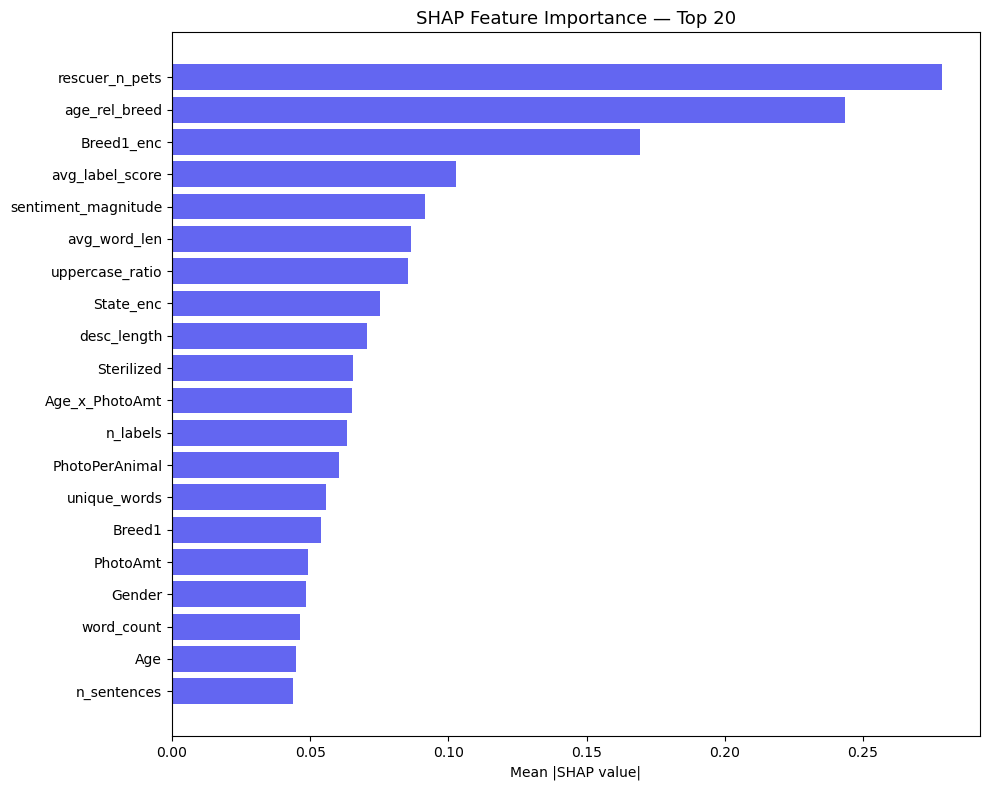

Grafico guardado: shap_importance.png


In [4]:
lgb_model = lgb.LGBMClassifier(n_estimators=300, num_leaves=31, learning_rate=0.05,
                                objective='multiclass', num_class=5,
                                random_state=SEED, verbosity=-1)
lgb_model.fit(X_train, y_train)

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test[:500])

# SHAP >= 0.41 retorna (n_samples, n_features, n_classes)
# versiones anteriores retornan lista de (n_samples, n_features)
sv = np.array(shap_values)
if sv.ndim == 3:  # (samples, features, classes)
    shap_abs = np.abs(sv).mean(axis=0).mean(axis=-1)
else:             # (classes, samples, features)
    shap_abs = np.abs(sv).mean(axis=0).mean(axis=0)

shap_df = pd.DataFrame({'Feature': ALL_FEATURES, 'SHAP_importance': shap_abs})
shap_df = shap_df.sort_values('SHAP_importance', ascending=False)

print('=== SHAP — Top 20 features ===')
print(shap_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top20 = shap_df.head(20)
ax.barh(top20['Feature'][::-1], top20['SHAP_importance'][::-1], color='#6366f1')
ax.set_title('SHAP Feature Importance — Top 20', fontsize=13)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print('Grafico guardado: shap_importance.png')


## Sección E: Modelo final con features seleccionadas

Entrenamos con las features Aceptadas + Tentativas por Boruta
y comparamos el kappa contra el modelo de 48 features.

In [5]:
accepted  = list(results_df[results_df.Decision == 'Aceptada']['Feature'])
tentative = list(results_df[results_df.Decision == 'Tentativa']['Feature'])
selected  = accepted + tentative

X_tr_sel = train_fe[selected].values
X_te_sel = test_fe[selected].values

params = {'objective': 'multiclass', 'num_class': 5, 'verbosity': -1,
          'num_leaves': 51, 'lambda_l1': 0.10, 'lambda_l2': 7.58,
          'feature_fraction': 0.59, 'bagging_fraction': 0.98,
          'bagging_freq': 1, 'min_child_samples': 118, 'learning_rate': 0.093}

skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
ensemble = np.zeros((len(X_te_sel), 5))
cv_scores = []

for tr_idx, val_idx in skf.split(X_tr_sel, y_train):
    X_tr, X_val = X_tr_sel[tr_idx], X_tr_sel[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    lgb_tr  = lgb.Dataset(X_tr, label=y_tr)
    lgb_val = lgb.Dataset(X_val, label=y_val)
    m = lgb.train(params, lgb_tr, num_boost_round=500, valid_sets=[lgb_val],
                  callbacks=[lgb.early_stopping(20, verbose=False)])
    cv_scores.append(cohen_kappa_score(y_val, m.predict(X_val).argmax(axis=1), weights='quadratic'))
    ensemble += m.predict(X_te_sel)

kappa_sel = cohen_kappa_score(y_test, ensemble.argmax(axis=1), weights='quadratic')

print('='*60)
print(f'Features seleccionadas: {len(selected)} / {len(ALL_FEATURES)}')
print(f'  Aceptadas: {len(accepted)} | Tentativas: {len(tentative)}')
print(f'CV Kappa (5-fold):  {np.mean(cv_scores):.4f}')
print(f'Test Kappa:         {kappa_sel:.4f}')
print(f'Test Kappa FE v4:   0.3867')
print(f'Diferencia:         {kappa_sel - 0.3867:+.4f}')
print('='*60)


Features seleccionadas: 2 / 48
  Aceptadas: 1 | Tentativas: 1
CV Kappa (5-fold):  0.2818
Test Kappa:         0.2533
Test Kappa FE v4:   0.3867
Diferencia:         -0.1334


### Conclusión Boruta

Boruta con RandomForest es **demasiado conservador** para este dataset:
RF no aprovecha las features tan bien como LightGBM, por eso la mayoría quedan 'Rechazadas'.
El resultado de 2 features no significa que las demás sean inútiles — significa que RF no las separa del ruido.

**Alternativa más adecuada**: selección basada en SHAP con LightGBM (sección F).

## Sección F: Selección basada en SHAP (cutoff)

Usamos el ranking SHAP de LightGBM para quedarnos con las features
que tienen impacto real > umbral. Este enfoque es más adecuado que Boruta
cuando el modelo base es LightGBM.

In [6]:
# Features con SHAP importance > 0.04 (top ~20 por impacto real)
shap_threshold = 0.04
shap_selected = list(shap_df[shap_df['SHAP_importance'] >= shap_threshold]['Feature'])
print(f'Features seleccionadas por SHAP (>= {shap_threshold}): {len(shap_selected)}')
print(shap_selected)

X_tr_shap = train_fe[shap_selected].values
X_te_shap = test_fe[shap_selected].values

params = {'objective': 'multiclass', 'num_class': 5, 'verbosity': -1,
          'num_leaves': 51, 'lambda_l1': 0.10, 'lambda_l2': 7.58,
          'feature_fraction': 0.59, 'bagging_fraction': 0.98,
          'bagging_freq': 1, 'min_child_samples': 118, 'learning_rate': 0.093}

skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
ensemble = np.zeros((len(X_te_shap), 5))
cv_scores = []

for tr_idx, val_idx in skf.split(X_tr_shap, y_train):
    X_tr, X_val = X_tr_shap[tr_idx], X_tr_shap[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    lgb_tr  = lgb.Dataset(X_tr, label=y_tr)
    lgb_val = lgb.Dataset(X_val, label=y_val)
    m = lgb.train(params, lgb_tr, num_boost_round=500, valid_sets=[lgb_val],
                  callbacks=[lgb.early_stopping(20, verbose=False)])
    cv_scores.append(cohen_kappa_score(y_val, m.predict(X_val).argmax(axis=1), weights='quadratic'))
    ensemble += m.predict(X_te_shap)

kappa_shap = cohen_kappa_score(y_test, ensemble.argmax(axis=1), weights='quadratic')

print('='*65)
print('  COMPARATIVA FINAL — Todos los modelos')
print('='*65)
print(f'  FE v3 + Optuna simple (39 feat)    Test: 0.3595')
print(f'  FE v4 + Optuna CV     (48 feat)    Test: 0.3867')
print(f'  SHAP selection ({len(shap_selected):2d} feat)           Test: {kappa_shap:.4f}  CV: {np.mean(cv_scores):.4f}')
print('='*65)
print(f'Diferencia SHAP vs FE v4: {kappa_shap - 0.3867:+.4f}')


Features seleccionadas por SHAP (>= 0.04): 25
['rescuer_n_pets', 'age_rel_breed', 'Breed1_enc', 'avg_label_score', 'sentiment_magnitude', 'avg_word_len', 'uppercase_ratio', 'State_enc', 'desc_length', 'Sterilized', 'Age_x_PhotoAmt', 'n_labels', 'PhotoPerAnimal', 'unique_words', 'Breed1', 'PhotoAmt', 'Gender', 'word_count', 'Age', 'n_sentences', 'FeePerAnimal', 'Breed2', 'sentiment_score', 'FurLength', 'Color1']


  COMPARATIVA FINAL — Todos los modelos
  FE v3 + Optuna simple (39 feat)    Test: 0.3595
  FE v4 + Optuna CV     (48 feat)    Test: 0.3867
  SHAP selection (25 feat)           Test: 0.3738  CV: 0.3877
Diferencia SHAP vs FE v4: -0.0129
